In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import math
import numpy as np
import pandas as pd
import random
import re

from torch.utils.data import DataLoader, Dataset, TensorDataset

In [2]:
df = pd.read_csv('/kaggle/input/for-transformer-train/for_transformer_train.csv')
df.shape

(804914, 5)

In [3]:
!pip install selfies

In [4]:
import selfies as sf

encodered_list = []

for i in range(len(df['cano_scaffold'])):
    try:
        scaffold_encode = sf.encoder(df['cano_scaffold'].iloc[i])  # smiles 인코딩
        scaffold_encode_split = list(sf.split_selfies(scaffold_encode))
  
        smiles_encode = sf.encoder(df['cano_smiles'].iloc[i])  # smiles 인코딩
        smiles_encode_split = list(sf.split_selfies(smiles_encode))
        
        encodered_list.append([
            df['cano_scaffold'].iloc[i],
            scaffold_encode_split,
            df['cano_smiles'].iloc[i],
            smiles_encode_split
        ])
    except:
        continue

    if len(encodered_list) == 300000:
        break

x_encoded = [['[SOS]'] + i[1] + ['[EOS]'] for i in encodered_list]
y_encoded = [['[SOS]'] + i[3] + ['[EOS]'] for i in encodered_list]

In [6]:
len(x_encoded), len(y_encoded)

(300000, 300000)

In [7]:
max_x_len = max([len(i) for i in x_encoded]) - 2
max_y_len = max([len(i) for i in y_encoded]) - 2

res_len = max(max_x_len, max_y_len)
res_len

45

In [8]:
x_encoded2 = [['[SOS]'] + i[1] + ['[EOS]'] + (res_len - len(i[1]))*['[PAD]'] for i in encodered_list]
y_encoded2 = [['[SOS]'] + i[3] + ['[EOS]'] + (res_len - len(i[3]))*['[PAD]'] for i in encodered_list]

In [9]:
np.array(x_encoded2).shape, np.array(y_encoded2).shape

((300000, 47), (300000, 47))

In [10]:
vocab = []

for i in x_encoded2:
    vocab += i

for j in y_encoded2:
    vocab += j

vocab = list(set(vocab))
token2id = {tok: i for i, tok in enumerate(vocab)}

x_ids = []
y_ids = []

for x_seq in x_encoded2:
	x_ids.append([token2id[tok] for tok in x_seq])

for y_seq in y_encoded2:
	y_ids.append([token2id[tok] for tok in y_seq])
 
X_tensor = torch.tensor(x_ids, dtype=torch.long)
y_tensor = torch.tensor(y_ids, dtype=torch.long)

train_dataset = TensorDataset(X_tensor, y_tensor)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [11]:
# 모든 입력/출력 토큰 합치기
all_tokens = torch.cat([X_tensor.flatten(), y_tensor.flatten()])

# 각 토큰별 등장 횟수 계산
unique, counts = torch.unique(all_tokens, return_counts=True)

# token id → 실제 토큰 매핑
id2token = {v: k for k, v in token2id.items()}

# 등장 횟수 높은 순 정렬
sorted_counts = sorted(zip(unique.tolist(), counts.tolist()), key=lambda x: x[1], reverse=True)

In [12]:
num_classes = len(token2id)
weights = torch.ones(num_classes)

# 빈도 기반 역비율 가중치
freq = torch.zeros(num_classes)
freq[unique] = counts.float()
weights = 1.0 / (freq + 1e-6)  
weights = weights / weights.sum() * num_classes  

# PAD는 무시
weights[token2id["[PAD]"]] = 0.0

In [13]:
class PositionalEncoding(nn.Module):
    def __init__(self, dim_model, dropout_p, max_len):
        super().__init__()
        # 드롭 아웃
        self.dropout = nn.Dropout(dropout_p) # Dropout(0.1)

        # Encoding - From formula
        pos_encoding = torch.zeros(max_len, dim_model) #(5000, 8) 크기의 0으로 채워진 배열 생성
        positions_list = torch.arange(0, max_len, dtype=torch.float).view(-1, 1) 
        # 0 ~ 5000까지의 배열 생성 = list(range(0,5001)) 근데 사이즈가 (5000,1)이라고 생각하면 됨
        division_term = torch.exp(torch.arange(0, dim_model, 2).float() * (-math.log(10000.0)) / dim_model) # 1000^(2i/dim_model)
  
        pos_encoding[:, 0::2] = torch.sin(positions_list * division_term)
        pos_encoding[:, 1::2] = torch.cos(positions_list * division_term)
        # 규칙적으로 짝수, 홀수 인덱스에 고유값을 부여해서 위치가 헷갈리지 않게 도와줌

        # Saving buffer (same as parameter without gradients needed)
        pos_encoding = pos_encoding.unsqueeze(0).transpose(0, 1) # [5000, 1, 8]로 변경
        self.register_buffer("pos_encoding",pos_encoding)

    def forward(self, token_embedding: torch.tensor) -> torch.tensor:
        # Residual connection + pos encoding
        return self.dropout(token_embedding + self.pos_encoding[:token_embedding.size(0), :])

In [14]:
class Transformer(nn.Module):
    def __init__(self, num_tokens, dim_model, num_heads,
                 num_encoder_layers, num_decoder_layers, dropout_p):
        super().__init__()

        self.dim_model = dim_model
        self.positional_encoder = PositionalEncoding(
            dim_model=dim_model,
            dropout_p=dropout_p,
            max_len=max(max_x_len, max_y_len)
        )
        self.embedding = nn.Embedding(num_tokens, dim_model)

        self.transformer = nn.Transformer(
            d_model=dim_model,
            nhead=num_heads,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dropout=dropout_p,
        )
        self.out = nn.Linear(dim_model, num_tokens)

    def forward(self, src, tgt, tgt_mask=None, src_pad_mask=None, tgt_pad_mask=None):
        # Embedding + positional encoding
        src = self.embedding(src) * math.sqrt(self.dim_model)
        tgt = self.embedding(tgt) * math.sqrt(self.dim_model)
        src = self.positional_encoder(src)
        tgt = self.positional_encoder(tgt)

        # (batch, seq, dim) → (seq, batch, dim)
        src = src.permute(1, 0, 2)
        tgt = tgt.permute(1, 0, 2)

        # Transformer
        transformer_out = self.transformer(
            src, tgt,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_pad_mask,
            tgt_key_padding_mask=tgt_pad_mask
        )  # (seq, batch, dim)

        # (seq, batch, dim) → (batch, seq, vocab)
        out = self.out(transformer_out).permute(1, 0, 2)
        return out

    def get_tgt_mask(self, size) -> torch.Tensor:
        mask = torch.tril(torch.ones(size, size)).to(torch.bool)
        mask = mask.float()
        mask = mask.masked_fill(mask == 0, float('-inf'))
        mask = mask.masked_fill(mask == 1, float(0.0))
        return mask

    def create_pad_mask(self, matrix: torch.Tensor, pad_token: int) -> torch.Tensor:
        return (matrix == pad_token)

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Transformer(num_tokens=len(token2id), dim_model=128, num_heads=4, num_encoder_layers=8, num_decoder_layers=8, dropout_p=0).to(device)
# d_model % nhead == 0은 반드시 맞춰야 함
opt = torch.optim.SGD(model.parameters(), lr=0.05)
weights = weights.to(device)
loss_fn = nn.CrossEntropyLoss(weights, ignore_index=token2id['[PAD]'])

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [16]:
def train_loop(model, opt, loss_fn, dataloader, pad_token_id):
    model.train()
    total_loss = 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        # 디코더 입력과 정답 분리
        y_input = y[:, :-1]
        y_expected = y[:, 1:]

        # 마스크 생성
        seq_len = y_input.size(1)
        tgt_mask = model.get_tgt_mask(seq_len).to(device)
        src_pad_mask = model.create_pad_mask(X, pad_token_id).to(device)
        tgt_pad_mask = model.create_pad_mask(y_input, pad_token_id).to(device)

        # Forward
        pred = model(
            X, y_input,
            tgt_mask=tgt_mask,
            src_pad_mask=src_pad_mask,
            tgt_pad_mask=tgt_pad_mask
        )  # (batch, seq_len-1, vocab)

        # Loss
        loss = loss_fn(
            pred.reshape(-1, pred.size(-1)),   # (batch*seq, vocab)
            y_expected.reshape(-1)             # (batch*seq)
        )

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [17]:
def validation_loop(model, loss_fn, dataloader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            X, y = batch[:, 0], batch[:, 1]
            X, y = torch.tensor(X, dtype=torch.long, device=device), torch.tensor(y, dtype=torch.long, device=device)

            y_input = y[:,:-1]
            y_expected = y[:,1:]

            sequence_length = y_input.size(1)
            tgt_mask = model.get_tgt_mask(sequence_length).to(device)

            pred = model(X, y_input, tgt_mask)

            pred = pred.permute(1, 2, 0)      
            loss = loss_fn(pred, y_expected)
            total_loss += loss.detach().item()

    return total_loss / len(dataloader)

In [19]:
def fit(model, opt, loss_fn, train_dataloader, epochs):  
    # 나중에 plotting 하기위해
    train_loss_list, validation_loss_list = [], []

    print("Training and validating model")
    for epoch in range(epochs):
        print("-"*25, f"Epoch {epoch + 1}","-"*25)

        train_loss = train_loop(model, opt, loss_fn, train_dataloader, token2id['[PAD]'])
        train_loss_list += [train_loss]

        # validation_loss = validation_loop(model, loss_fn, val_dataloader)
        # validation_loss_list += [validation_loss]

        print(f"Training loss: {train_loss:.4f}")
        # print(f"Validation loss: {validation_loss:.4f}")
        print()

    return train_loss_list

train_loss_list = fit(model, opt, loss_fn, train_dataloader, 5)

Training and validating model
------------------------- Epoch 1 -------------------------
Training loss: 1.4595

------------------------- Epoch 2 -------------------------
Training loss: 1.2488

------------------------- Epoch 3 -------------------------
Training loss: 1.0895

------------------------- Epoch 4 -------------------------
Training loss: 1.0115

------------------------- Epoch 5 -------------------------
Training loss: 0.9310



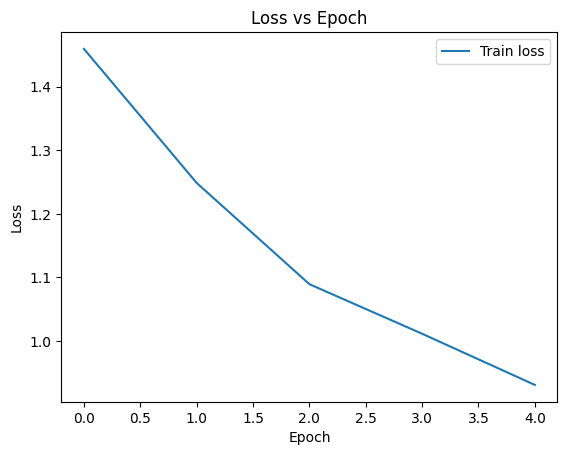

In [20]:
import matplotlib.pyplot as plt

plt.plot(train_loss_list, label = "Train loss")
# plt.plot(validation_loss_list, label = "Validation loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

In [21]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 51.6 MB/s eta 0:00:00:00:0100:01


In [22]:
def predict(model, input_sequence, max_length=max(max_x_len, max_y_len), SOS_token=token2id['[SOS]'], EOS_token=token2id['[EOS]']):
    model.eval()

    y_input = torch.tensor([[SOS_token]], dtype=torch.long, device=device)

    num_tokens = len(input_sequence[0])

    for _ in range(max_length):
        # Get source mask
        tgt_mask = model.get_tgt_mask(y_input.size(1)).to(device)

        pred = model(input_sequence, y_input, tgt_mask)

        next_item = pred.topk(1)[1].view(-1)[-1].item() # num with highest probability
        next_item = torch.tensor([[next_item]], device=device)

        # Concatenate previous input with predicted best word
        y_input = torch.cat((y_input, next_item), dim=1)

        # Stop if model predicts end of sentence
        if next_item.view(-1).item() == EOS_token:
            break

    return y_input.view(-1).tolist()

from rdkit import Chem
new_scaffold = 'c1ccccc1'
cano_scaffold = Chem.MolToSmiles(Chem.MolFromSmiles(new_scaffold), canonical=True)
sca_list = list(sf.split_selfies(sf.encoder(new_scaffold)))
token_sca_list = [token2id[i] for i in sca_list]

res = [token2id['[SOS]']] + token_sca_list + [token2id['[EOS]']] + [token2id['[PAD]']]*(max_x_len-len(token_sca_list))

# Here we test some examples to observe how the model predicts
res
example = torch.tensor([res], dtype=torch.long, device=device)


result = predict(model, example)
print(f"Example {1}")
print(f"Input: {example.view(-1).tolist()[1:-1]}")
print(f"Continuation: {result[1:-1]}")
print()

Example 1
Input: [41, 26, 41, 26, 41, 26, 55, 45, 2, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25]
Continuation: [11, 61, 52, 0, 11, 3, 41, 26, 18, 35, 45, 41, 14, 22, 41, 26, 52, 39, 11, 3, 45, 41, 14, 52, 41, 30, 30, 52, 41, 30, 30, 26, 55, 0, 47]



In [23]:
def find_key_by_value(d, value):
    return [k for k, v in d.items() if v == value]

In [24]:
sf_string = ''.join([find_key_by_value(token2id, i)[0] for i in result[1:-1]])
res_to_smiles,attr = sf.decoder(sf_string,attribute=True)
print(res_to_smiles)

O=P(OPC=C[CH1-1][N+1]=O)[O-1]


In [25]:
from rdkit import Chem

mol = Chem.MolFromSmiles(res_to_smiles)

if mol is None:
    print("❌ 화학적으로 유효하지 않은 구조")
else:
    print("✅ 유효한 분자")
    print("Canonical SMILES:", Chem.MolToSmiles(mol))

✅ 유효한 분자
Canonical SMILES: O=[N+][CH-]C=CPO[PH](=O)[O-]


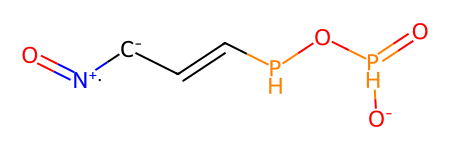

In [26]:
mol

In [31]:
torch.save(model, 'model.pt')

Example 1
Input: [41, 26, 41, 26, 41, 26, 55, 45, 2, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25]
Continuation: [11, 61, 52, 0, 11, 3, 41, 26, 18, 35, 45, 41, 14, 22, 41, 26, 52, 39, 11, 3, 45, 41, 14, 52, 41, 30, 30, 52, 41, 30, 30, 26, 55, 0, 47]

O=P(OPC=C[CH1-1][N+1]=O)[O-1]


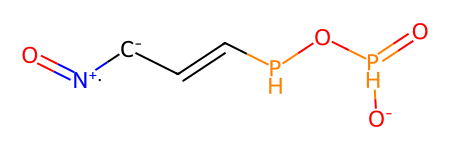

In [35]:
model2 = torch.load('/kaggle/working/model.pt',weights_only=False) 

new_scaffold = 'c1ccccc1'
cano_scaffold = Chem.MolToSmiles(Chem.MolFromSmiles(new_scaffold), canonical=True)
sca_list = list(sf.split_selfies(sf.encoder(new_scaffold)))
token_sca_list = [token2id[i] for i in sca_list]

res = [token2id['[SOS]']] + token_sca_list + [token2id['[EOS]']] + [token2id['[PAD]']]*(max_x_len-len(token_sca_list))

# Here we test some examples to observe how the model predicts
res
example = torch.tensor([res], dtype=torch.long, device=device)


result = predict(model, example)
print(f"Example {1}")
print(f"Input: {example.view(-1).tolist()[1:-1]}")
print(f"Continuation: {result[1:-1]}")
print()

sf_string = ''.join([find_key_by_value(token2id, i)[0] for i in result[1:-1]])
res_to_smiles,attr = sf.decoder(sf_string,attribute=True)
print(res_to_smiles)

mol = Chem.MolFromSmiles(res_to_smiles)

mol